# 🏠😊💷💶 Keeping Up With The Jones:- Predictive Modelling

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

## Set Up directories and Import Necessary Libraries

In [1]:
# System and OS related tasks
import sys
import os

# Add the project root to Python path
project_root = os.path.abspath('..')
sys.path.insert(0, project_root)

# path to directories
raw_dir = '../data/raw'
processed_dir = '../data/processed'

In [2]:
# Get the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pingouin as pg

sns.set_style('whitegrid') # sets a white background with grid lines 

In [3]:
# Get data:

filename = "2a_df_regional_wellbeing_6countries_mainland.csv"

df_regional_wellbeing_6countries_mainland = pd.read_csv(
    f"{processed_dir}/{filename}",
    )

df_regional_wellbeing_6countries_mainland.head(3)

,xls_row_id,country,region,region_code,disposable_income_pc,employment_rate,unemployment_rate,homicide_rate,life_expectancy,secondary_education_pct,...,mortality_rate,voter_turnout_pct,broadband_access_pct,air_quality_pm25,life_satisfaction_index,housing_affordability_pct,internet_speed_deviation,social_network_support_index,country_iso3,north_south
0,111,France,Île-de-France,FR1,35629.0,68.7,7.9,1.0,84.9,84.1,...,6.9,76.0,94.2,12.7,6.7,43.4,55.0,88.8,FRA,Other
1,112,France,Centre-Val de Loire,FRB,30823.6,70.7,5.8,0.8,82.6,86.5,...,8.3,75.0,87.4,8.9,6.4,47.9,53.2,88.5,FRA,Other
2,113,France,Bourgogne-Franche-Comté,FRC,30839.7,68.9,6.6,0.6,82.3,82.0,...,8.4,77.1,83.9,9.8,6.7,41.5,45.8,95.4,FRA,Other


---

# 1.0 Predictive Modelling

📌 In the previous notebook of hypothesis testings, we have looked at the familiar "North-South Divide" narrative across the dimensions of wealth, health and happiness. Hypotheses 1 and 3 confirmed that Northern region tend to have lower disposable income and life expectancy but that there is no apparent difference in life satisfaction as compared to its Southern neighbours.

📌 When we look at the relationships amongst these dimensions within UK and compared it to the selected 5 European nations, we found that all three relationship showed meaning differences. The most interesting was the income-health relations whereby the UK regions showed a strong positive correlation (r = 0.66) while the chosen European counterparts showed no relation at all (r = -0.08). The income-happiness link is also stronger in the European five (r = 0.39) than the UK (r = 0.18), giving the impression taht money buys more happiness elsewhere than it does in the UK.

📌 In this notebook, we will attempt to create the following predictive models to explore these relationships further:
* Model 1: `MVP` _**"The Baseline"**_ Income predicts happiness for all regions (baseline)
* Model 2: `MVP` _**"The Joneses Comparison"**_ Includes the UK as a variable so as to acertain if UK regions are systematically happier or unhappier than the European regions on the similar income.
* Model 3: `Coud Have` _**"Health and Happiness"**_ For the UK alone, does health adds anything to the prediction of happiness beyond income. 

---

# 2.0 Predictive Model 1: "The Baseline"

📌 This model aims to test whether income can predict happiness across regions.

## 2.1 Split the Data into Train and Test

In [4]:
m1_want_col_list = ["disposable_income_pc", "life_expectancy", "life_satisfaction_index"]

df_model1 = df_regional_wellbeing_6countries_mainland.copy()

df_model1 = df_regional_wellbeing_6countries_mainland[m1_want_col_list]

df_model1.head(3)

,disposable_income_pc,life_expectancy,life_satisfaction_index
0,35629.0,84.9,6.7
1,30823.6,82.6,6.4
2,30839.7,82.3,6.7


In [5]:
df_model1.describe()

,disposable_income_pc,life_expectancy,life_satisfaction_index
count,91.000000,91.000000,91.000000
mean,30828.120879,82.342857,6.728571
std,4661.675464,1.527972,0.423553
min,21391.700000,79.200000,5.500000
25%,28015.000000,81.300000,6.400000
50%,30498.400000,82.300000,6.700000
75%,33958.700000,83.650000,7.000000
max,47301.700000,85.400000,7.600000


In [6]:
# double check for missing values
print(df_model1.isnull().sum())

disposable_income_pc       0
life_expectancy            0
life_satisfaction_index    0
dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
                                    df_model1.drop(['life_satisfaction_index'], axis=1), # for the X dependent variables& dropping the target variable
                                    df_model1['life_satisfaction_index'],# add the target valurable
                                    test_size=0.2, # 80/20 split into train and test
                                    random_state=101  # set the seed for the random generator for the splitting process
                                    )

print(
    "* Train set:",
    X_train.shape,
    y_train.shape,
    "\n* Test set:",
    X_test.shape,
    y_test.shape,
)

* Train set: (72, 2) (72,) 
* Test set: (19, 2) (19,)


## 2.2 Build the Pipeline

📌  The `StandardScaler` is used so that features like `life_expectancy` with double digit values will not be overwhelmed by `disposable_income_pc` with large values.

📌  We will rely on the feature selector `Lasso` as it can automatically select features that are useful by setting unused features' coefficient to zero. As we have only 2 features to play with, we will set `alpha` to be very small to keep as many features as necessary.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel

def pipeline_linear_regression():
    """
    Create a pipeline for linear regression.

    This function creates a pipeline that performs feature scaling, feature selection,
    and linear regression modeling.

    Returns:
        pipeline (Pipeline): The pipeline object that performs the specified steps.
    """
    pipeline = Pipeline([
        ("feat_scaler", StandardScaler()),
        ("feat_selector", SelectFromModel(Lasso(alpha=0.01))),  # 0.01 so Lasso keeps as many features as possible
        ("model", LinearRegression())
    ])
    return pipeline

pipeline_linear_regression()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feat_scaler', ...), ('feat_selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.",Lasso(alpha=0.01)
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",None
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1


## 2.3 Teach the Machine for Fitting

📌 Get the trained linear regression model's intercept and coefficients using the function (author of the function is Code Institute).

In [9]:
def linear_model_coefficients(model, columns):
    """
    Print the intercept and coefficients of a linear model.

    Parameters:
    model (object): The trained linear model object.
    columns (array-like): The column names corresponding to the coefficients.

    Returns:
    None
    """
    print(f"* Interception: {model.intercept_}")
    coeff_df = pd.DataFrame(model.coef_, columns, columns=["Coefficient"]).sort_values(
        ["Coefficient"], key=abs, ascending=False
    )
    print("* Coefficients")
    print(coeff_df)

📌 Create and train the pipeline

In [10]:
# Create the pipeling
pipeline = pipeline_linear_regression()

# Train the pipeline
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feat_scaler', ...), ('feat_selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.",Lasso(alpha=0.01)
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",None
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1


📌 Inspect the trained linear regression model from the pipeline

In [11]:
pipeline['model']

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


📌 Look at which features are selected for the trained linear regression model:

In [12]:
pipeline['feat_selector'].get_support()

array([ True,  True])

 * The `lasso` selector has included both `disposable_income_ps` and `lofe_expectancy`

In [13]:
X_train.columns[pipeline['feat_selector'].get_support()]

Index(['disposable_income_pc', 'life_expectancy'], dtype='str')

📌 Get the intercept and the coefficients using the handy function `linear_model_coefficients`. 

In [14]:
linear_model_coefficients(
    model=pipeline['model'],
    columns=X_train.columns[pipeline['feat_selector'].get_support()])

* Interception: 6.7027777777777775
* Coefficients
                      Coefficient
disposable_income_pc     0.172781
life_expectancy         -0.123007


📌 Look at the predicted min and max `life_satisfaction_index` values from the model. 

In [15]:
print(f"The min predicted life_satisfaction_index: {pipeline.predict(X_test).min()}")
print(f"The min predicted life_satisfaction_index: {pipeline.predict(X_test).max()}")

The min predicted life_satisfaction_index: 6.586444876879412
The min predicted life_satisfaction_index: 6.988909078679335


* whilst the range of min and max looks small, the 6 nation data showed that the `life_satisfaction_index` was between the range of 5.5 to 7.5.

📌 The linear regression model is:

>
>`Happiness`  = 6.7 + (0.17 × `Income`) + (-0.12 × `Health`)
>
or more accurately:
>
>`life_satisfaction_index`  = 6.702778 + (0.172781 × `disposabble_income_pc`) + (-0.123007 × `life_expectancy`)
>

📌🔍📈 What the linear regression model is saying:
* when income and health is zero, the hapiness is 6.7.
  * In reality, this does not make any sense as one cannot be 6.7 (out of 10) satisfied with life when one is not alive.
* the income is positively related to the yield. For every US$1 increase in disposable income, the happiness index would increase by 0.173.
  * this does not go against the common notion that wealth brings happinesses (to a certain extent)
* the health is negatively related to the happiness index such that for every 1 year of life, the happiness index would drop by 0.123.

📌🔍🕵🏻‍♂️ At first glance, it is at least a bit disconcerting and counter-intuitive to see that happiness and health are negatively related to each other as we have been conditioned to think that
* longer life probably means better healthcare and quality of life and hence happier people

However, there are could be myraids of reasons for this straight line relationship between health and happiness:
* the life satisfaction index is a subjective one so it is largely depending on the cultural influence and personal perspective on what is a "satisfied life". 
* regions with older populations might have lower satisfaction due to loneliness and health issues.
* we have seen that Italy and Spain have high life expectancies (median of 83-84 years) but lower life satisfaction (around 6.4) then say the UK (81 years / 6.9 ) or the Netherlands (82 years / 7.4)
* The model reveals that life expectancy alone does not buy happiness.
  * Obviously, other factors socio-economic factors will come into play.


# 2.4 Evaluate the Model

📌 Using the code from the Code Institute's lecture: 

In [16]:
# import regression metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error 
# we will use numpy to calculate RMSE based on MSE (mean_squared_error)
import numpy as np


def regression_performance(X_train, y_train, X_test, y_test, pipeline):
    """
    Gets train/test sets and pipeline and evaluates the performance
    for each set (train and test) by calling regression_evaluation()
    which will evaluate the pipeline performance.
    is called by regression_evaluation(X, y, pipeline) as defined below

    Parameters:
    - X_train: The input features of the training set.
    - y_train: The target values of the training set.
    - X_test: The input features of the test set.
    - y_test: The target values of the test set.
    - pipeline: The regression pipeline to evaluate.

    Returns:
    None
    """

    print("Model Evaluation \n")
    print("* Train Set")
    regression_evaluation(X_train, y_train, pipeline)
    print("* Test Set")
    regression_evaluation(X_test, y_test, pipeline)


def regression_evaluation(X, y, pipeline):
    """
    Gets features and target (either from train or test set) and pipeline.
    
    Args:
        X (array-like): The input features.
        y (array-like): The target values.
        pipeline (object): The trained pipeline for regression.
    
    Returns:
        None
    
    Prints the following performance metrics comparing the prediction to the target:
    - R² (R-Squared) Score: How much variance is explained by the model? 0.6 = 60% of house price variation can be explained by the features
    - Mean Absolute Error
    - Mean Squared Error
    - Root Mean Squared Error
    """
    prediction = pipeline.predict(X)
    print("R2 Score:", round(r2_score(y, prediction),3))
    print("Mean Absolute Error:", round(mean_absolute_error(y, prediction),3))
    print("Mean Squared Error:", round(mean_squared_error(y, prediction),3))
    print(
        "Root Mean Squared Error:", round(np.sqrt(mean_squared_error(y, prediction)),3)
    )
    print("\n")

  

def regression_evaluation_plots(X_train, y_train, X_test, y_test, pipeline, alpha_scatter=0.5):
    """
    Gets Train and Test set (features and target), pipeline, and adjusts dots transparency
    at scatter plot.

    Parameters:
    - X_train (array-like): Training set features.
    - y_train (array-like): Training set target.
    - X_test (array-like): Test set features.
    - y_test (array-like): Test set target.
    - pipeline (object): Trained regression pipeline.
    - alpha_scatter (float, optional): Transparency level for scatter plot dots. Default is 0.5.

    Returns:
    None

    Functionality:
    - Predicts on the train and test set using the provided pipeline.
    - Creates Actual vs Prediction scatterplots for the train and test set.
    - Draws a red diagonal line. In theory, a good regressor should predict
        close to the actual, meaning the dot should be close to the diagonal red line.
        The closer the dots are to the line, the better.
    - Displays the scatterplots.
    """

# the pipeline defined above inherit the .predict() method from sklearn.pipeline.pipeline
    pred_train = pipeline.predict(X_train)  # Get predictions for training data
    pred_test = pipeline.predict(X_test)    # Get predictions for testing data

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    # plot the training data
    sns.scatterplot(x=y_train, y=pred_train, alpha=alpha_scatter, ax=axes[0])
    sns.lineplot(x=y_train, y=y_train, color="red", ax=axes[0])
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predictions")
    axes[0].set_title("Train Set")

    # plot the testing data
    sns.scatterplot(x=y_test, y=pred_test, alpha=alpha_scatter, ax=axes[1])
    sns.lineplot(x=y_test, y=y_test, color="red", ax=axes[1])
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predictions")
    axes[1].set_title("Test Set")

    plt.show()

📌 Now, evaluate the model:

Model Evaluation 

* Train Set
R2 Score: 0.254
Mean Absolute Error: 0.288
Mean Squared Error: 0.143
Root Mean Squared Error: 0.379


* Test Set
R2 Score: -0.006
Mean Absolute Error: 0.242
Mean Squared Error: 0.11
Root Mean Squared Error: 0.332




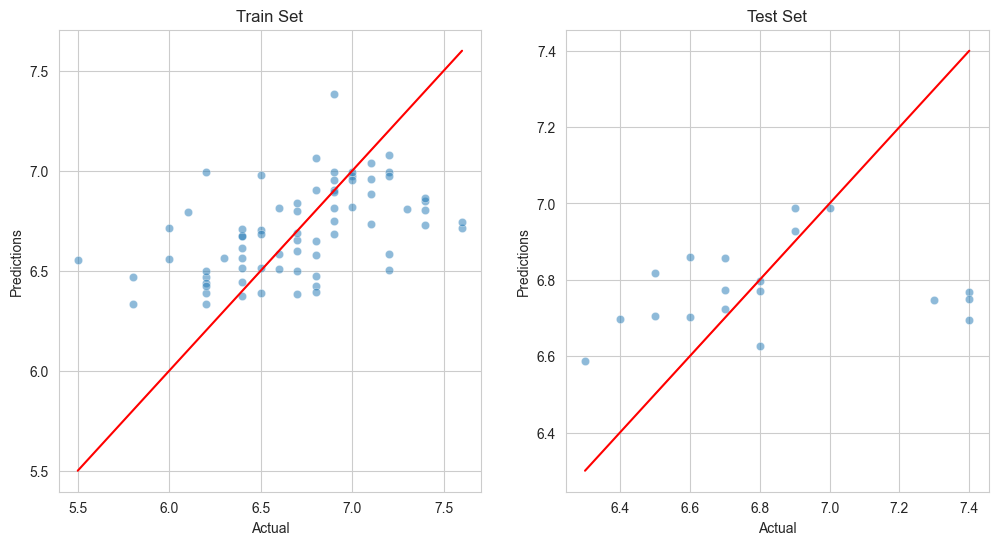

In [17]:
# 1. Get numerical metrics
regression_performance(X_train, y_train, X_test, y_test, pipeline)

# 2. Get visual diagnostics
regression_evaluation_plots(
    X_train, y_train, X_test, y_test, pipeline, alpha_scatter=0.5
)

📌🔍🕵🏻‍♂️ Model Evaluation:
* With a R<sup>2</sup> value of 0.254 and -0.006 on the Training and on the Test data respectively, the model is not performing well. 
  * On the Train set 
    * The model only explain 25.4% (a small portion) of the happiness
    * The MAE or the average prediction error of 0.29 points on a 0-10 scale.
  * On the Test set 
    * The model performs worst than the Train set!
    * The MAE or the average prediction error of 0.242 which is lower than tht train set.
* It looks like the model has overfitted:
  * With the Train R<sup>2</sup> bigger than the Test R<sup>2</sup>, it looks like the model has learned the training data but for which it cannot apply the learning to the test data
  * the model has practically no predictive power on the test data even though the test errors are better than the Train (RMSE of 0.332 for the Test vs 0.379 for the Train)
* The overfitting probably occurs becuase of the small number of observations and simple features
  * Despite being overfitted, Model 1 still provides valuable information about the joint effect of income and health and the level of happiness.
  * In section 2.5, we will refit the model with all training data.
* Now that we know that wealth and health cannot predict happiness for all the regions in the selected six European nations, the real drivers of happiness factor


## 2.5 Model 1A: Use all data for Training only

📌 To split the dataset of 91 observations into Train and Test of 73 and 18 observations respectively might lead to a overfitting on the train data and bad prediction on the test data.

This section will to use all the 91 observations to fit the model.

In [18]:
X1_train = df_model1[["disposable_income_pc", "life_expectancy"]]

y1_train = df_model1["life_satisfaction_index"]

In [19]:
# Create the pipeling
pipeline1 = pipeline_linear_regression()

# Train the pipeline
pipeline1.fit(X1_train, y1_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feat_scaler', ...), ('feat_selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.",Lasso(alpha=0.01)
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",None
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1


In [20]:
pipeline1['feat_selector'].get_support()

array([ True,  True])

In [21]:
X1_train.columns[pipeline1['feat_selector'].get_support()]

Index(['disposable_income_pc', 'life_expectancy'], dtype='str')

In [22]:
linear_model_coefficients(
    model=pipeline1['model'],
    columns=X1_train.columns[pipeline['feat_selector'].get_support()])

* Interception: 6.728571428571428
* Coefficients
                      Coefficient
disposable_income_pc     0.146316
life_expectancy         -0.140428


In [23]:
regression_evaluation(X1_train, y1_train, pipeline1)

R2 Score: 0.236
Mean Absolute Error: 0.281
Mean Squared Error: 0.136
Root Mean Squared Error: 0.368




📌🔍🕵🏻‍♂️ Model 1B Evaluation:
* even with all the 91 observations, the Model 1A can only explain less than 25% of the variation (R<sup>2</sup>) which is roughly the same as Model 1.
* Between Model 1 and Model 1A, the impact of the 
  ** income coefficient has decreased from 0.173 to 0.146 and 
  ** health coefficient has increased from -0.123 to -0.140

## 2.6 Model 1/Model 1A Conclusion:

📌🔍🕵🏻‍♂️ Even by using all 91 observations on what would be the baseline model of predicting happiness from wealth and health, the models can only explain about 25% of the variations. The persistent negative relation of health to happiness _**may be**_ an interesting find as this seemingly counter-intuitive pattern suggests that perhaps the relationship between health and subjective measurements of happiness is not straightforward and is probably affected by cultural and soci0-economic factors that are not capture in this analysis. 

The following are possible speculations for the negative relationship between health and happiness and are not meant to be definitive or exhaustive:
* We have established in the EDA that in the six European nations, the southern nations have higher life expectancy (perhaps due to their Mediterranean diet) but lower life satisfaction compared to the northern neighbours which could be due to cultural differences in deciding what is life satisfaction.
* That there might be a urban-rural divide where urban areas have better healthcare access lower happiness levels due to stress of being in a city.
* Or even as quirky as, region with better healthcare might lead to its residents being more anxious about health! 

---

# 3.0 Predictive Model 2: "Everything but the Kitchen Sink"

📌 Model 1 (and Model 1a) demonstrated that income and health can only explain a quarter of the variation in happiness across the six nations. Hence, this raise the next logical quesion: how about the other dimensions of well-being?

📌 In addition to `life_satisfaction_index` , the OECD's social well-being data contains the following dimensions:
* Material conditions:
  * `disposable income per capita`
  * `employment_rate`
  * `unemployment_rate`
  * `rooms_per_capita` 
  * `housing_affordability_pct` 
* Health
  * `life_expectancy`
  * `mortality_rate` 
* Safety
  * `homicide_rate`
* Education
    * `secondary_education_pct` 
* Environment
  * `air_quality_pm25` 
* Digital Access
  * `broadband_access_pct` 
  * `internet_speed_deviation` 
* Civic engagements and Social Connections:
  * `voter_turnout_pct` 
  * `social_network_support_index`


In [25]:
df_regional_wellbeing_6countries_mainland.columns

Index(['xls_row_id', 'country', 'region', 'region_code',
       'disposable_income_pc', 'employment_rate', 'unemployment_rate',
       'homicide_rate', 'life_expectancy', 'secondary_education_pct',
       'rooms_per_capita', 'mortality_rate', 'voter_turnout_pct',
       'broadband_access_pct', 'air_quality_pm25', 'life_satisfaction_index',
       'housing_affordability_pct', 'internet_speed_deviation',
       'social_network_support_index', 'country_iso3', 'north_south'],
      dtype='str')

## 3.1 Split the Data into Train and Test

In [26]:
m2_want_col_list = ['disposable_income_pc'
                    , 'employment_rate'
                    , 'unemployment_rate'
                    , 'homicide_rate'
                    , 'life_expectancy'
                    , 'secondary_education_pct'
                    , 'rooms_per_capita'
                    , 'mortality_rate'
                    , 'voter_turnout_pct'
                    , 'broadband_access_pct'
                    , 'air_quality_pm25'
                    , 'life_satisfaction_index'
                    , 'housing_affordability_pct'
                    , 'internet_speed_deviation'
                    , 'social_network_support_index']

df_model2 = df_regional_wellbeing_6countries_mainland.copy()

df_model2 = df_regional_wellbeing_6countries_mainland[m2_want_col_list]

df_model2.head(3)

,disposable_income_pc,employment_rate,unemployment_rate,homicide_rate,life_expectancy,secondary_education_pct,rooms_per_capita,mortality_rate,voter_turnout_pct,broadband_access_pct,air_quality_pm25,life_satisfaction_index,housing_affordability_pct,internet_speed_deviation,social_network_support_index
0,35629.0,68.7,7.9,1.0,84.9,84.1,1.5,6.9,76.0,94.2,12.7,6.7,43.4,55.0,88.8
1,30823.6,70.7,5.8,0.8,82.6,86.5,2.0,8.3,75.0,87.4,8.9,6.4,47.9,53.2,88.5
2,30839.7,68.9,6.6,0.6,82.3,82.0,2.0,8.4,77.1,83.9,9.8,6.7,41.5,45.8,95.4


In [27]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
                                    df_model2.drop(['life_satisfaction_index'], axis=1), # for the X dependent variables& dropping the target variable
                                    df_model2['life_satisfaction_index'],# add the target valurable
                                    test_size=0.2, # 80/20 split into train and test
                                    random_state=101  # set the seed for the random generator for the splitting process
                                    )

print(
    "* Model 2 Train set:",
    X2_train.shape,
    y2_train.shape,
    "\n* Model 2 Test set:",
    X2_test.shape,
    y2_test.shape,
)

* Model 2 Train set: (72, 14) (72,) 
* Model 2 Test set: (19, 14) (19,)


## 3.2 Teach the Machine for Fitting

📌 Using the same pipeline as Model 1:

In [28]:
pipeline_linear_regression()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feat_scaler', ...), ('feat_selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.",Lasso(alpha=0.01)
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",None
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1


In [29]:
# Create the pipeline
pipeline2 = pipeline_linear_regression()

# Train the pipeline
pipeline2.fit(X2_train, y2_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feat_scaler', ...), ('feat_selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.",Lasso(alpha=0.01)
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",None
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1


📌 Inspect the trained linear regression model from the pipeline

In [30]:
pipeline2['model']

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


📌 Look at which features are selected for the trained linear regression model:

In [31]:
pipeline2['feat_selector'].get_support()

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True])

 * The `lasso` selector has included all but `air_quality_pm25`.

In [33]:
X2_train.columns[pipeline2['feat_selector'].get_support()]

Index(['disposable_income_pc', 'employment_rate', 'unemployment_rate',
       'homicide_rate', 'life_expectancy', 'secondary_education_pct',
       'rooms_per_capita', 'mortality_rate', 'voter_turnout_pct',
       'broadband_access_pct', 'housing_affordability_pct',
       'internet_speed_deviation', 'social_network_support_index'],
      dtype='str')

📌 Get the intercept and the coefficients using the handy function `linear_model_coefficients`. 

In [35]:
linear_model_coefficients(
    model=pipeline2['model'],
    columns=X2_train.columns[pipeline2['feat_selector'].get_support()])

* Interception: 6.702777777777777
* Coefficients
                              Coefficient
mortality_rate                  -0.276473
life_expectancy                 -0.253990
voter_turnout_pct                0.238049
social_network_support_index     0.117287
unemployment_rate               -0.100354
internet_speed_deviation        -0.086645
homicide_rate                    0.067163
disposable_income_pc             0.060190
housing_affordability_pct       -0.059285
employment_rate                 -0.055915
rooms_per_capita                -0.043700
secondary_education_pct          0.037542
broadband_access_pct             0.024310


📌 Look at the predicted min and max `life_satisfaction_index` values from the model. 

📌 The multivariate linear regression model on happiness (life_satisfaction_index) has the collowing features and feature's coefficients:

| Dimension | Indicator | Coefficient | Rank |
|:---|:---|:---|:---|
| **Material Conditions** | `disposable_income_pc` | <div style="text-align: right">0.060</div> | <div style="text-align: center">8</div> |
| | `employment_rate` | <div style="text-align: right">-0.056</div> | <div style="text-align: center">10</div> |
| | `unemployment_rate` | <div style="text-align: right">-0.100</div> | <div style="text-align: center">5</div> |
| | `rooms_per_capita` | <div style="text-align: right">-0.044</div> | <div style="text-align: center">11</div> |
| | `housing_affordability_pct` | <div style="text-align: right">-0.059</div> | <div style="text-align: center">9</div> |
| **Health** | `life_expectancy` | <div style="text-align: right">-0.254</div> | <div style="text-align: center">2<sup>nd</sup></div> |
| | `mortality_rate` | <div style="text-align: right">-0.276</div> | <div style="text-align: center">1<sup>st</sup></div> |
| **Safety** | `homicide_rate` | <div style="text-align: right">0.067</div> | <div style="text-align: center">7</div> |
| **Education** | `secondary_education_pct` | <div style="text-align: right">0.038</div> | <div style="text-align: center">12</div> |
| **Environment** | `air_quality_pm25` | <div style="text-align: right">*discarded by Lasso*</div> | <div style="text-align: center">n.a.</div> |
| **Digital Access** | `broadband_access_pct` | <div style="text-align: right">0.024</div> | <div style="text-align: center">13</div> |
| | `internet_speed_deviation` | <div style="text-align: right">-0.087</div> | <div style="text-align: center">6</div> |
| **Civic Engagement & Social Connections** | `voter_turnout_pct` | <div style="text-align: right">0.238</div> | <div style="text-align: center">3<sup>rd</sup></div> |
| | `social_network_support_index` | <div style="text-align: right">0.117</div> | <div style="text-align: center">4</div> |


In [36]:
print(f"The min predicted life_satisfaction_index: {pipeline2.predict(X2_test).min()}")
print(f"The min predicted life_satisfaction_index: {pipeline2.predict(X2_test).max()}")

The min predicted life_satisfaction_index: 6.541733014190311
The min predicted life_satisfaction_index: 7.194788468389478


* whilst the range of min and max looks small, the 6 nation data showed that the `life_satisfaction_index` was between the range of 5.5 to 7.5.

📌🔍📈 What this multivariate linear regression model is saying:
* Material Conditions
  * all the dimensions in this category have small coefficients and have mixed effects on happiness.
  * ''unemployment_rate` is the 5<sup>th</sup> most important feature with a small negative value of 0.1. The negative relationship is something that one would expect.
  * `disposable_income_pc` is the 8<sup>th</sup> most important feature with a positive but small value of 0.060. Note that this coefficient is much reduced from the 0.146316 of Model 1A
  * `employment_rate` is the 10<sup>th</sup> most important feature with a small but surprising negative value of 0.056
* Health 
  * Both the dimension have strong and negative coefficients.
  * The seemingly _**"counterintuitive"_ finding of `life-expectancy` having a negative effect on happiness appears to persist.
  * However, higher `motality_rate` does relative negatively `life_satisfaction_index`
* Safety
  * `homicide_rate` is the 7th most important feature and surprising positively related to `life_satisfaction_index`.
* Education
  * is the penultimate most important feature and it has a very small positive relationship with happiness
* Environment
  * has been excluded by Lasso and deemed to be unimportant or could be correlated with other features.
  * or it might be that the `air_quality_pm25` with values ranging from 5 to 25µg/m³ is so small that  a 1µg/m³ change in air quality is judged by Lasso as too weak compared to other predictors despite applying the StandardScaler.
* Digital Access
  * `internet_speed_deviation` measures the average deviation from OECD average (%). Esentially, it is a measure on the inequality of broadband quality. A high value indicates a diital dividl within the region. It is the 6th (out of 13) most important feature and has a negative relation to happiness which translates to "more unequal speeds (within a region) predict lower happiness". 
* Civic Engagement and Social Connections
  * the 2 features `voter_turnout_pct` and `social_network_support_index` in this category are the 3<sup>rd</sup> and 4<sup>th</sup> most important features. 
  * they both have positive relations which means that social interactions and involve are important for happiness.

📌🔍🕵🏻‍♂️ Material conditions showed surprising (or not) weak and inconsistent relationships with happiness. Health indicators showed inconsistent correlations despite being the top two most important indicators for happiness. The other important features are social interactions and involvement showing that regions where people turn out to vote and have strong social networks are consistentlly happier. This could explain why the UK has a North-South divide on weatlth and health but are equally happy as a whole.


## 3.3 Evaluate the Model

Model Evaluation 

* Train Set
R2 Score: 0.633
Mean Absolute Error: 0.195
Mean Squared Error: 0.071
Root Mean Squared Error: 0.266


* Test Set
R2 Score: 0.572
Mean Absolute Error: 0.185
Mean Squared Error: 0.047
Root Mean Squared Error: 0.216




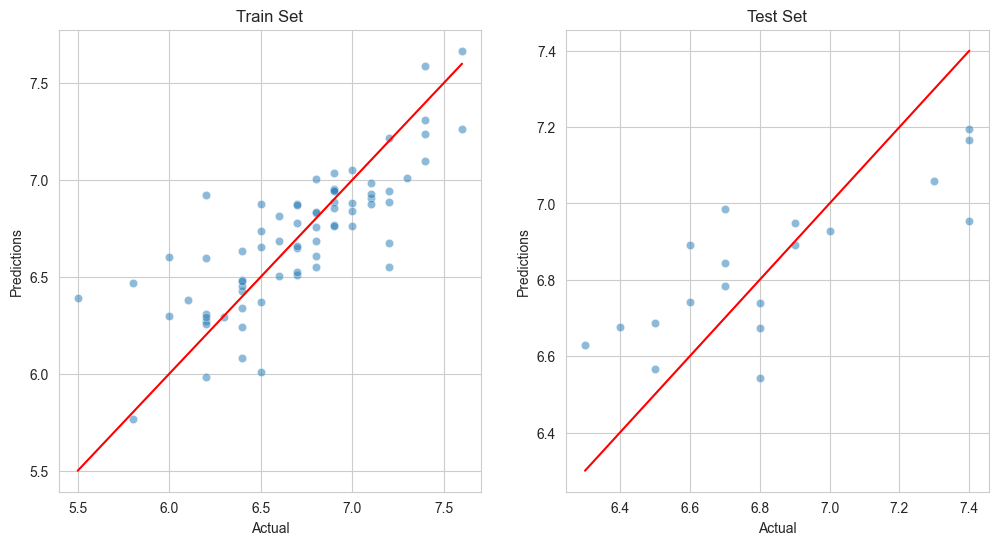

In [37]:
# 1. Get numerical metrics
regression_performance(X2_train, y2_train, X2_test, y2_test, pipeline2)

# 2. Get visual diagnostics
regression_evaluation_plots(
    X2_train, y2_train, X2_test, y2_test, pipeline2, alpha_scatter=0.5
)

---

# 4.0 Predictive Model 3??: 

📌

## 4.1 Split the Data into Train and Test

## 4.2 Build the Pipeline

## 4.3 Teach the Machine for Fitting

## 4.4 Evaluate the Model

---

# 5.0 Conclusion, Limitations and Ethical Considerations:

📌

---